<a href="https://colab.research.google.com/github/EvagAIML/001A-APPLIED-classification-models/blob/main/Techniques_to_address_the_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Augmentation

**Data Augmentation** is a powerful technique used to artificially increase the size of the training dataset by generating new, slightly modified versions of the existing data. This is particularly useful when the dataset is small, and the model tends to overfit (i.e., performs very well on training data but poorly on unseen test data).

###Why Data Augmentation Helps with Overfitting
Overfitting occurs when a model learns to memorize the training data rather than generalizing to unseen data. In this case, the model becomes highly sensitive to the specific training examples, capturing noise and irrelevant patterns instead of the underlying relationships.

###Data Augmentation helps by:
* Increasing the diversity of the training data: Augmentation generates new variations of the existing data, making the model less sensitive to specific training examples.
* Preventing the model from memorizing the dataset: By exposing the model to different versions of the same data, it is forced to generalize better to unseen examples.
* Acting as regularization: Similar to dropout, augmentation prevents the model from over-relying on specific features and forces it to learn more robust and generalized patterns.

###Common Data Augmentation Techniques
* **Geometric Transformations:**
  * Rotation: Rotating the images by a random degree (e.g., between -40 to 40 degrees).
  * Flipping: Horizontally or vertically flipping the images.
  * Cropping: Randomly cropping a part of the image to create variations.
  * Zooming: Randomly zooming in or out of an image.
  * Translation: Shifting the image along the horizontal or vertical axis.

* **Color Space Augmentation:**
  * Brightness adjustment: Randomly changing the brightness of the image.
  * Contrast adjustment: Randomly increasing or decreasing contrast.
  * Saturation adjustment: Modifying color saturation.

* **Noise Injection:**
  * Adding noise: Randomly adding noise (like Gaussian noise) to the images to make the model more robust to imperfections.

* **Elastic Distortions:**
  * Slightly warping or stretching the images to simulate variations that might appear in real-world data.

* **Random Erasing:**
  * Randomly erasing a small part of the image during training to encourage the model to focus on the relevant features of the image.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator instance with augmentation options
datagen = ImageDataGenerator(
    rotation_range=40,         # Rotate the image by up to 40 degrees
    width_shift_range=0.2,     # Shift the image horizontally by up to 20% of the width
    height_shift_range=0.2,    # Shift the image vertically by up to 20% of the height
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Random zoom in/out
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill in new pixels created by augmentations
)

# Example: Assume 'X_train' contains the training images
# Fit the generator to the training data
datagen.fit(X_train)

# Model training with augmented data
model.fit(datagen.flow(X_train, y_train, batch_size=32),
          steps_per_epoch=len(X_train) / 32, epochs=50)


10 augmented images saved to '/content/drive/MyDrive/py/AIML/Introduction to Computer Vision/Week 2 - Transfer Learning/MLS 2 - Transfer Learning/augmented_images'.


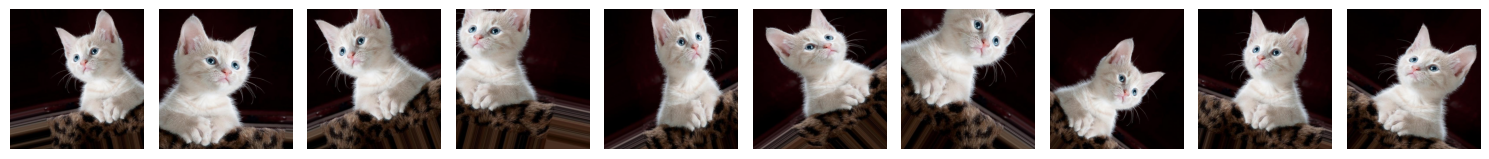

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Path to a sample image
input_image_path = '/content/drive/MyDrive/py/AIML/Introduction to Computer Vision/Week 2 - Transfer Learning/MLS 2 - Transfer Learning/cat.jpg'
output_dir = '/content/drive/MyDrive/py/AIML/Introduction to Computer Vision/Week 2 - Transfer Learning/MLS 2 - Transfer Learning/augmented_images'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load and convert image to array
img = load_img(input_image_path)  # Load as PIL image
img_array = img_to_array(img)     # Convert to Numpy array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Define ImageDataGenerator with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate and save 10 augmented images
i = 0
for batch in datagen.flow(img_array, batch_size=1,
                          save_to_dir=output_dir,
                          save_prefix='aug',
                          save_format='jpeg'):
    i += 1
    if i >= 10:
        break  # Stop after generating 10 images

print(f"10 augmented images saved to '{output_dir}'.")

# Optional: Display a few of them
fig, ax = plt.subplots(1, 10, figsize=(15, 5))
for idx, file in enumerate(sorted(os.listdir(output_dir))[:10]):
    image = load_img(os.path.join(output_dir, file))
    ax[idx].imshow(image)
    ax[idx].axis('off')
plt.tight_layout()
plt.show()


###Augmentation Parameters:
* rotation_range: Randomly rotates images up to 40 degrees.
* width_shift_range and height_shift_range: Randomly shifts the image horizontally or vertically.
* zoom_range: Applies random zoom-in or zoom-out.
* horizontal_flip: Flips the image horizontally, which is especially useful for symmetry in images (e.g., flipping a dog image will still be a valid dog image).


###Other Augmentation Examples:
1. Text Data Augmentation:
For text data, augmentation can be done by:
  * Synonym Replacement: Replacing words with their synonyms to create slightly different sentences.
  * Back Translation: Translating the sentence into another language and then back to the original language to create variations.
2. Audio Data Augmentation:
For audio data, you can:
  * Add noise: Introduce random noise to simulate real-world sounds.
  * Change pitch: Modify the pitch to create variation.
  * Time-stretching: Speeding up or slowing down the audio clip.


#Batch Normalization

**Batch Normalization** is a widely used technique in deep learning to make neural networks train faster and more stable. While its primary purpose is to address issues related to training (like internal covariate shift), **Batch Normalization** also helps reduce overfitting by improving regularization and reducing dependency on other regularization techniques such as dropout.

##How Batch Normalization Helps with Overfitting
Batch Normalization addresses overfitting in several ways:

* **Regularization Effect:**

Although Batch Normalization is not a traditional regularization method like L2 regularization or dropout, it has a regularization effect. By normalizing the inputs to each layer, it introduces noise during training, similar to what happens in dropout.
This noise is caused by the stochastic nature of mini-batches, meaning each batch is normalized slightly differently. This slight perturbation helps prevent the model from relying too heavily on specific features and forces it to generalize better across the data.

* **Reduces Internal Covariate Shift:**

In deep networks, the distribution of activations in one layer changes as the parameters of previous layers change. This shift makes training slow and difficult. Batch Normalization normalizes the output of each layer, keeping the distribution of the inputs to each layer more stable. This stabilization helps the model converge faster and learn better representations, which reduces the risk of overfitting.

* **Enables Higher Learning Rates:**

Batch Normalization allows for higher learning rates without the risk of divergence. Higher learning rates lead to faster convergence, reducing the likelihood of overfitting since the model doesn't have too much time to memorize the training data.

* **Reduces Sensitivity to Weight Initialization:**

Proper weight initialization is important to ensure good training. With Batch Normalization, the network becomes less sensitive to the specific values of initial weights. This prevents situations where the network starts overfitting because of poor weight initialization, making training more robust.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# Example of a simple feedforward neural network with batch normalization
model = Sequential()

# Input layer
model.add(Dense(128, input_shape=(784,)))  # Assume input is 784-dimensional (e.g., flattened MNIST images)
model.add(BatchNormalization())            # Apply Batch Normalization
model.add(Activation('relu'))              # Activation applied after batch normalization

# Hidden layer
model.add(Dense(64))
model.add(BatchNormalization())            # Apply Batch Normalization
model.add(Activation('relu'))

# Output layer
model.add(Dense(10, activation='softmax')) # 10 classes (e.g., for classification)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val))


##Where to Apply Batch Normalization
* After fully connected (Dense) layers: You can apply batch normalization right after the linear transformation (Dense layer) and before the non-linear activation function (e.g., ReLU, sigmoid). This helps ensure that the activations are well-scaled and less prone to overfitting.

* After convolutional layers: Batch Normalization works well with convolutional layers and is often applied before the activation function, similar to how it’s done with dense

##Finally, Batch Normalization allows the use of higher learning rates because:
* It stabilizes training by preventing exploding or vanishing gradients.
* It reduces sensitivity to weight initialization.
* It acts as a regularizer, preventing overfitting.
* It improves gradient flow and ensures consistent learning across layers.

#Spatial Dropout

**Spatial Dropout** is a variation of the traditional Dropout technique that is specifically designed for convolutional neural networks (CNNs). Like regular Dropout, its primary purpose is to address overfitting during training. However, it is tailored to the structure of CNNs, where preserving the spatial relationships between pixels or features is critical.

##What is Spatial Dropout?
While traditional dropout works well for fully connected (dense) layers, it is less effective for convolutional layers because:

* Convolutional layers operate on feature maps, where the spatial relationships between the features are crucial.
* Dropping individual pixels (or elements) from these feature maps breaks this spatial structure, which can hurt the model’s ability to learn meaningful spatial hierarchies.

**Spatial Dropout** addresses this by randomly dropping entire feature maps (channels), rather than individual elements within feature maps. This preserves the spatial coherence within each feature map while still providing the benefits of dropout by regularizing the network.

##How Spatial Dropout Works
* During training, Spatial Dropout works by zeroing out entire feature maps (i.e., a full channel across all spatial locations).
* If a feature map is dropped, none of its activations contribute to the forward pass in that iteration.
* This forces the model to rely on other feature maps to make predictions, encouraging it to learn more robust and independent features across the feature maps, thus preventing overfitting.

##Why Use Spatial Dropout for CNNs?
In CNNs, the model learns spatial hierarchies—from low-level features (e.g., edges and textures) to high-level features (e.g., objects). Preserving these spatial relationships is critical for the success of the network.

Traditional dropout applied to individual elements in a feature map might distort this spatial structure, reducing the network's ability to learn effectively.

Spatial Dropout, however, keeps the spatial structure intact while still regularizing the network by dropping entire channels. This way, it forces the network to utilize different subsets of feature maps in each forward pass, helping the network generalize better and reducing overfitting.

##Key Differences Between Dropout and Spatial Dropout

|Dropout	| Spatial Dropout|  
| --- | --- |
| Drops individual neurons randomly. | Drops entire feature maps (channels). |  
| Effective for fully connected layers. | Effective for convolutional layers. |
| Disrupts spatial correlations. | Preserves spatial correlations. |  
| Aimed at fully connected networks. | Aimed at convolutional networks. |  


##How Spatial Dropout Helps Reduce Overfitting
1. Encourages Redundant Features: By dropping entire feature maps during training, Spatial Dropout forces the model to learn redundant but useful features from different parts of the image. This prevents the model from over-relying on specific feature maps and promotes more generalized feature learning.

2. Acts as Regularization: Like traditional Dropout, Spatial Dropout introduces noise in the training process, which makes the model more robust and prevents it from memorizing the training data. This regularization effect reduces the risk of overfitting.

3. Prevents Feature Map Co-adaptation: In CNNs, feature maps can sometimes co-adapt, meaning the model becomes too reliant on certain feature maps to make decisions. By randomly dropping feature maps during training, Spatial Dropout ensures that the network does not rely too much on any one feature map, which improves generalization.

4. Helps in Small Datasets: When dealing with small datasets, overfitting is a common issue because the model tends to memorize the small amount of data it has seen. Spatial Dropout helps introduce variability during training and ensures that the model can generalize better to unseen data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, SpatialDropout2D

# Create a CNN model with Spatial Dropout
model = Sequential()

# First convolutional layer with Spatial Dropout
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(SpatialDropout2D(0.3))  # Apply Spatial Dropout with dropout rate of 30%

# Second convolutional layer with Spatial Dropout
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(SpatialDropout2D(0.3))  # Apply Spatial Dropout

# Flatten and fully connected layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))  # For classification with 10 classes

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val))


##When to Use Spatial Dropout
* **Convolutional Layers:** Spatial Dropout is specifically designed for CNNs and should be applied to convolutional layers where the spatial structure of feature maps is important.
* **Preventing Overfitting in CNNs:** When a CNN is showing signs of overfitting, especially when the training accuracy is much higher than validation accuracy, using Spatial Dropout can help regularize the model.
* **Small Datasets:** If the dataset is relatively small, CNNs are particularly prone to overfitting. Spatial Dropout can improve generalization in such cases.

##Advantages of Spatial Dropout
* **Maintains Spatial Structure:** Unlike traditional dropout, which disrupts spatial relationships in CNNs, Spatial Dropout maintains the spatial integrity of feature maps while still providing regularization.
* **Regularization for CNNs:** Spatial Dropout is specifically tailored for convolutional layers, making it more effective than traditional dropout in CNN architectures.
* **Improved Generalization:** By dropping entire feature maps, the network is encouraged to learn more diverse and redundant representations, reducing overfitting and improving generalization.
* **Easily Implementable:** Spatial Dropout can be easily integrated into any existing CNN architecture by replacing traditional dropout with SpatialDropout2D.

##Limitations
* **Drop Rate Needs to Be Tuned:** The dropout rate (percentage of feature maps to drop) needs to be carefully tuned. Dropping too many feature maps can lead to underfitting, where the model does not learn effectively.
* **Not for Fully Connected Layers:** Spatial Dropout is specifically designed for convolutional layers. For fully connected layers, traditional dropout is more appropriate.

#Transfer Learning

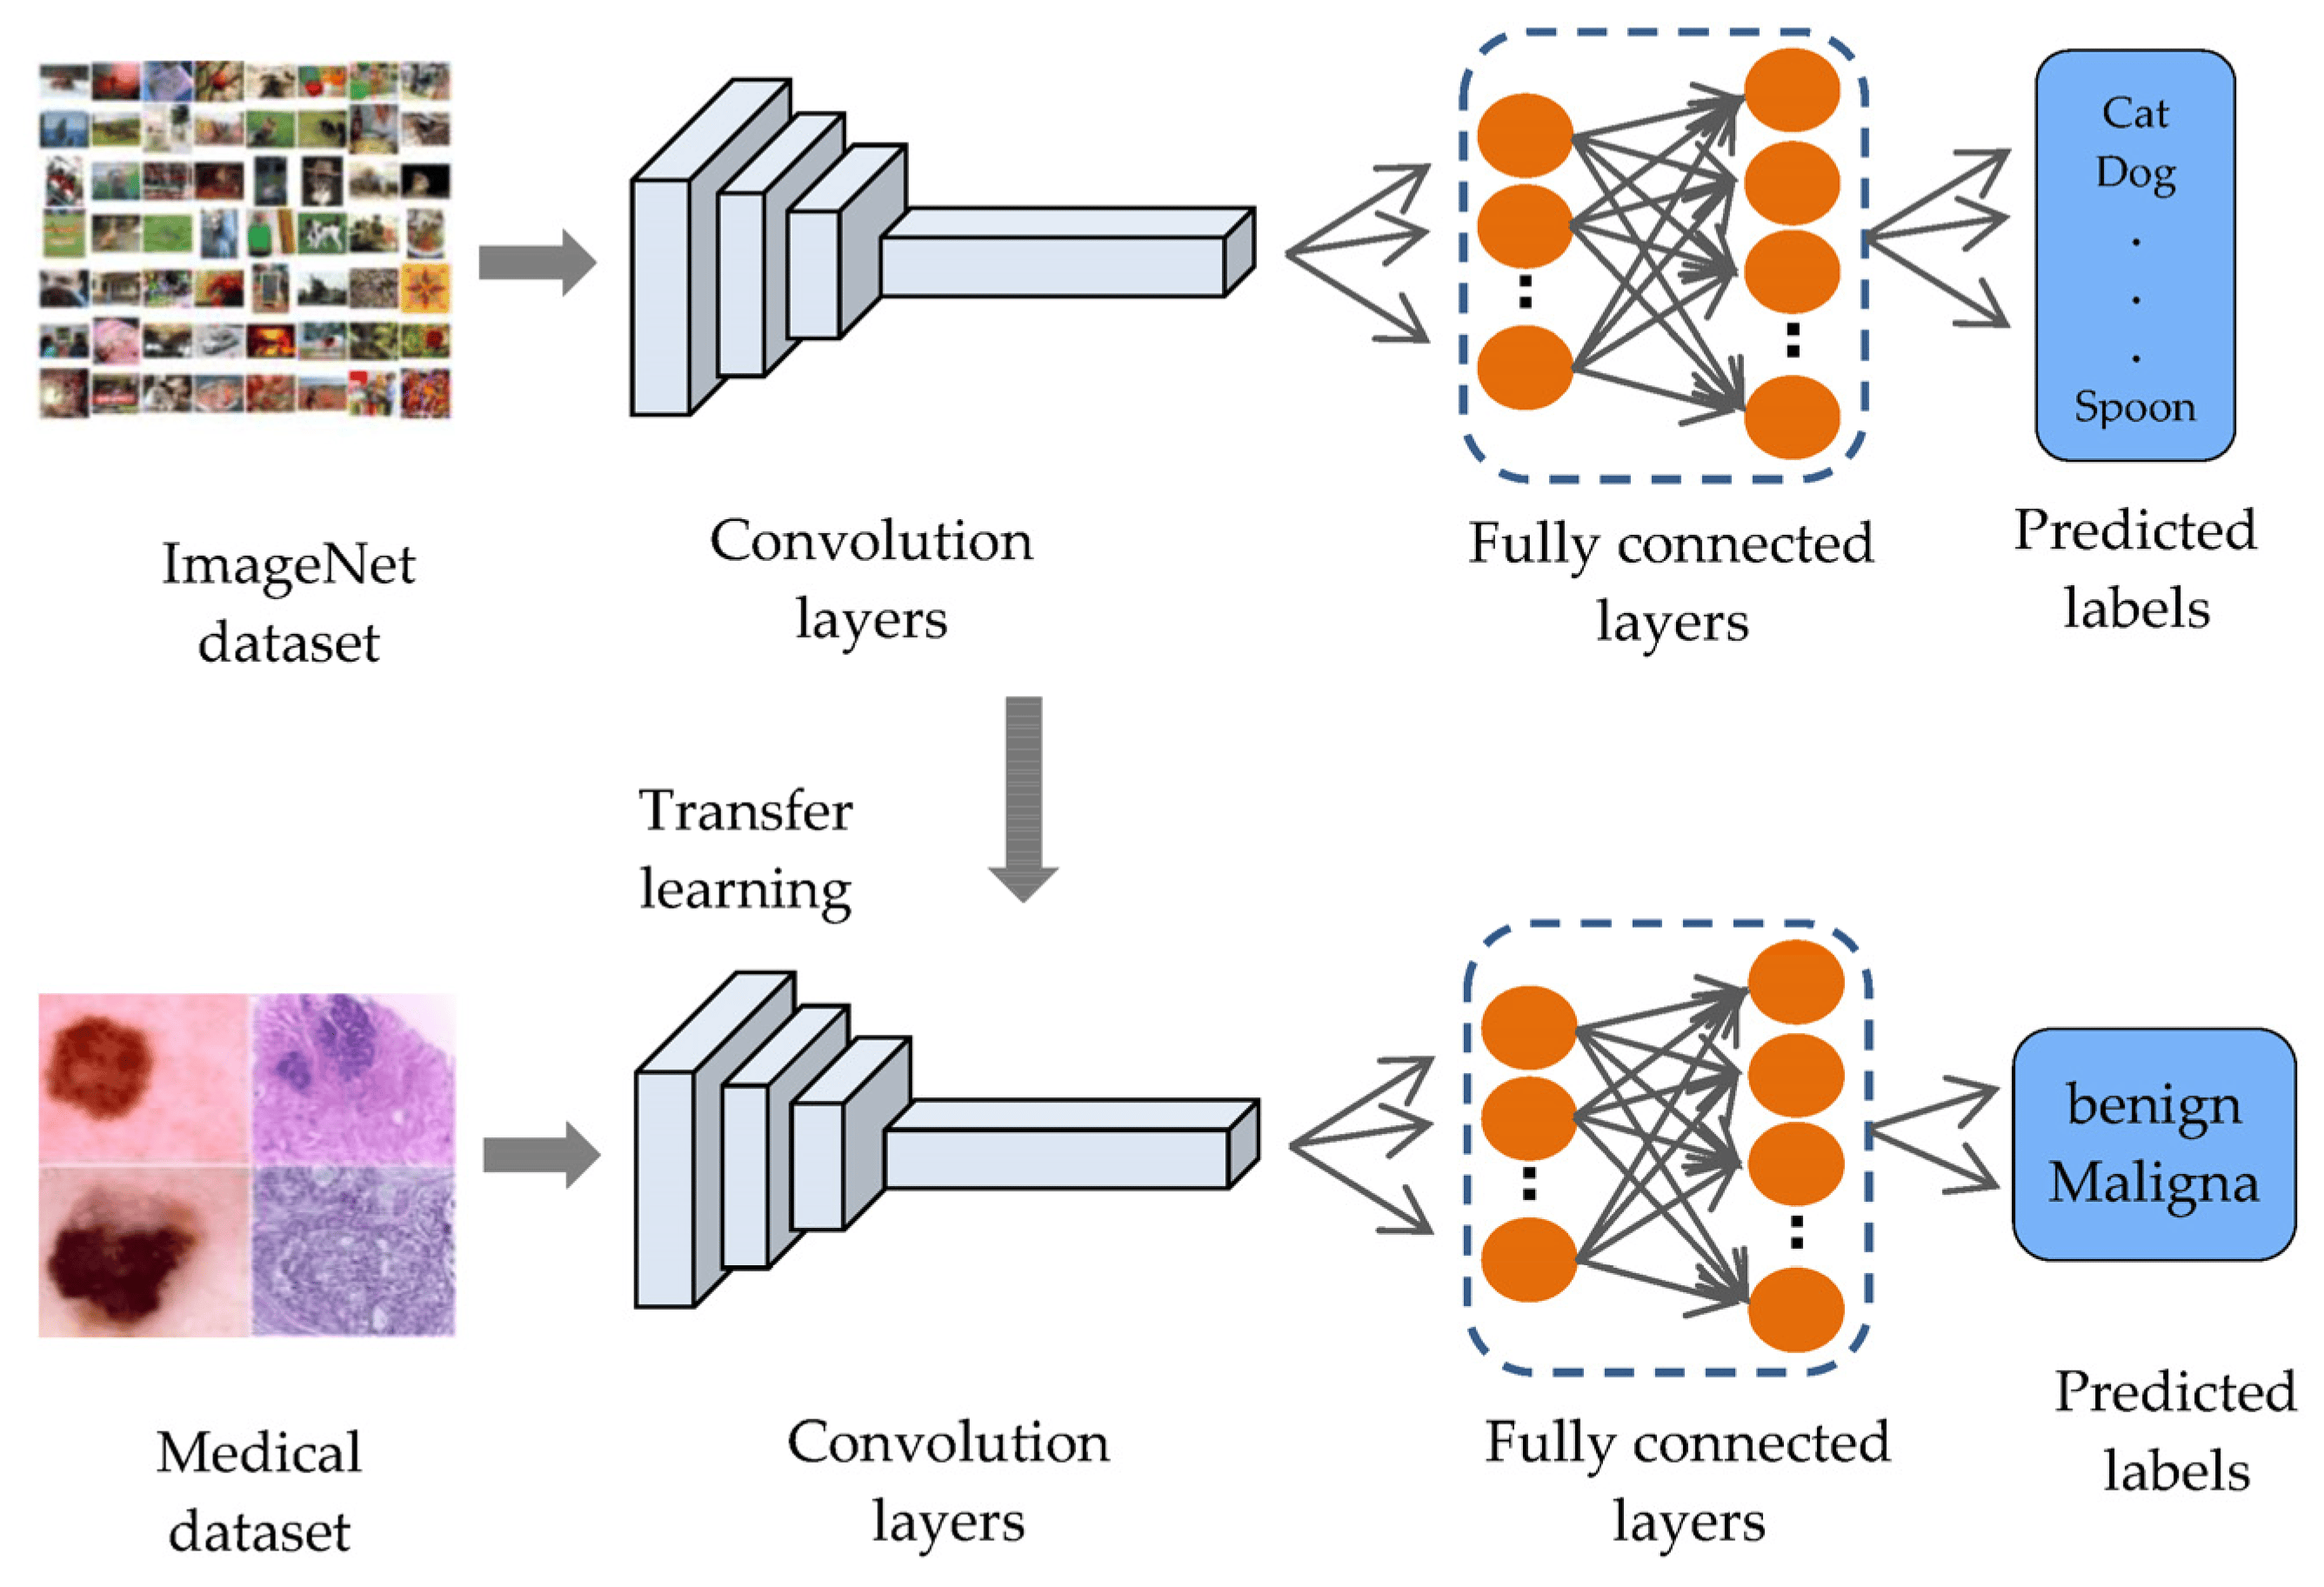

**ransfer Learning** is a machine learning technique where a model developed for one task is reused as the starting point for a model on a second related task. Instead of training a model from scratch, transfer learning leverages the patterns, representations, or features learned by a pre-trained model on a large dataset and applies them to a new task with a potentially smaller or related dataset.

This approach is highly beneficial in scenarios where:

1. The new dataset is small or difficult to label.
2. Training from scratch would require large computational resources and time.
3. Pre-trained models on related tasks exist and can be adapted efficiently.

##Key Concepts in Transfer Learning
1. **Pre-trained Model:**

A model that has been previously trained on a large dataset, usually on a general task such as image classification on ImageNet (a dataset of over a million images with 1,000 different object categories).
Common pre-trained models include VGG, ResNet, Inception, BERT (for NLP), and GPT.

2. **Transfer of Knowledge:**

  * In transfer learning, the knowledge learned in one domain (source task) is transferred and applied to another task (target task). The knowledge can be in the form of learned weights, features, or patterns from a deep learning model.

3. **Feature Extraction vs. Fine-tuning:**

  * Feature Extraction: When the pre-trained model’s weights are kept frozen (not updated during training) and only the final layers are trained for the specific task.
  * Fine-tuning: When you unfreeze some layers of the pre-trained model and train those layers along with the new task-specific layers, allowing for adjustments to better adapt the model to the new task.

##How Transfer Learning Works
In transfer learning, you typically follow these steps:

1. Choose a Pre-trained Model: Select a model that has been pre-trained on a large dataset (e.g., ImageNet for images, or a language model like BERT for text). The model should have been trained on a task similar to the one you are working on.

2. Modify the Model:

  * **Replace the final output layer:** The pre-trained model will have been trained to output predictions for its original task (e.g., 1000 classes in ImageNet). You typically remove this output layer and replace it with a new layer(s) suited to your target task (e.g., 10 classes for a new classification problem).
  * **Adjust Input Size (if necessary):** If your input data has a different size (e.g., 64x64 images instead of 224x224), you may need to adjust the input shape accordingly.
3. Freeze or Fine-tune Layers:

  * **Freezing Layers:** If using the pre-trained model as a feature extractor, you freeze the weights of the earlier layers (meaning these weights will not be updated during training), and only train the final classification layers.
  * **Fine-tuning Layers:** Alternatively, you can "fine-tune" some or all layers of the pre-trained model by allowing their weights to be updated during training. This is usually done after training the final layers first, as it requires careful learning rate adjustment to avoid disrupting the pre-learned representations.
4. Train on the Target Dataset:
  * Train the modified model on the new dataset for the new task. Depending on whether you are using feature extraction or fine-tuning, you will either train the new layers only or both the new layers and pre-trained layers.

##Feature Extraction Example

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Load the VGG16 model with pre-trained weights from ImageNet
# include_top=False removes the final fully connected layers used for ImageNet classification
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the base model
model = Sequential()

# Add the base pre-trained model
model.add(base_model)

# Add new layers on top for our specific task (e.g., binary classification)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (only the top layers are trained)
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


##Advantages of Transfer Learning
1. **Faster Training:** Transfer learning speeds up training because the model starts with pre-trained weights and doesn’t need to learn from scratch.
2. **Improves Performance on Small Datasets:** Transfer learning is particularly useful when you have a small dataset but want to leverage the power of a model trained on a much larger dataset.
3. **Reduces Computational Resources:** By using pre-trained models, you save on computational costs that would have been required to train a model from scratch.
4. **Utilizes Learned Representations:** Pre-trained models have already learned useful features like edges, textures, and shapes (in the case of images) or language patterns (in the case of NLP), which can be effectively transferred to new tasks.



##Challenges of Transfer Learning
1. Domain Mismatch (Task and Data Differences)
  * **Challenge:** Transfer learning works best when the source task (on which the model was pre-trained) is closely related to the target task. If there is a significant difference between the source and target domains, the pre-trained model’s features may not transfer effectively.
  * **Example:** A model pre-trained on natural images (e.g., ImageNet) may not perform well on a dataset of medical images like X-rays or MRI scans, since the learned features (e.g., object edges, textures) might not be relevant in the new domain.
  * **Solution:** In such cases, more extensive fine-tuning may be needed to adapt the model, or a pre-trained model from a more similar domain should be used.

2. Overfitting During Fine-tuning
* **Challenge:** When fine-tuning a pre-trained model on a small target dataset, there is a risk of overfitting. Fine-tuning updates the weights of the model, and if the target dataset is too small, the model might memorize the training data instead of generalizing to unseen data.
* **Solution:** To reduce overfitting, you can:
    * Use data augmentation to artificially increase the size of the dataset.
    * Freeze more layers of the pre-trained model and only fine-tune the later layers.
    * Use regularization techniques such as dropout, weight decay, or early stopping.
    * Adjust the learning rate carefully, starting with a lower learning rate for fine-tuning.

3. Catastrophic Forgetting
* **Challenge:** Catastrophic forgetting happens when fine-tuning causes the model to "forget" the useful representations and knowledge it learned during pre-training. This can occur when the model is over-tuned on the new dataset, which leads to poor performance on the new task.
* **Solution:**
    * Gradual unfreezing: Instead of unfreezing all layers at once, unfreeze the layers gradually, starting from the top (final layers) and working backward. This allows the model to retain useful general knowledge from the source task while adapting to the new task.
    * Use low learning rates during fine-tuning to prevent drastic updates to the pre-trained weights.

4. Memory and Computational Constraints
* **Challenge:** Many pre-trained models, especially in deep learning, are large and complex, requiring significant memory and computational resources to store and fine-tune. For example, models like BERT, ResNet, or GPT-3 can have millions or even billions of parameters, making them difficult to deploy on resource-limited environments (e.g., mobile devices).
* **Solution:**
    * Use model compression techniques such as pruning, quantization, or knowledge distillation to reduce the size of the model without significantly sacrificing performance.
    * Alternatively, you can use smaller pre-trained models like DistilBERT (a smaller version of BERT) or lightweight CNN architectures like MobileNet.

5. Fine-tuning Hyperparameters
* **Challenge:** Fine-tuning a pre-trained model requires careful adjustment of hyperparameters, such as the learning rate, the number of layers to freeze/unfreeze, and batch size. Improper hyperparameter settings can lead to overfitting or underfitting.
* **Solution:** Perform hyperparameter tuning using techniques like grid search or random search to find the best set of hyperparameters for your task. Additionally, start with lower learning rates when fine-tuning, as larger updates can destabilize the pre-trained weights.

6. Transferability of Features
* **Challenge:** Not all features learned by the pre-trained model are useful for the new task. Some layers of the pre-trained model may contain irrelevant or task-specific features that don't generalize well to the new task.
* **Solution:**
    * Perform layer-wise analysis to determine which layers of the pre-trained model contribute most to the performance on the new task. Layers closer to the input typically capture more general features (e.g., edges, shapes), while deeper layers capture task-specific features.
    * You can freeze the earlier layers (which capture general features) and fine-tune the later layers (which capture task-specific features) based on the needs of your task.

7. Negative Transfer
* **Challenge:** Sometimes, transferring knowledge from a pre-trained model can hurt performance, particularly if the source and target tasks are too dissimilar. This is known as negative transfer. In such cases, the pre-trained features may actually confuse the model or lead to suboptimal representations for the target task.
* **Example:** Using a model pre-trained on human facial recognition for an animal classification task may result in negative transfer, as the features learned for identifying human faces may not be useful for classifying animals.
* **Solution:**
    * Carefully choose a pre-trained model whose domain is more closely related to the target task.
    * If negative transfer is suspected, it may be better to train a model from scratch or use a more appropriate pre-trained model for the specific domain.

8. Limited Control Over Pre-trained Models
* **Challenge:** When using a pre-trained model, you may not have full control over how the model was trained (e.g., the dataset, biases in the dataset, and the specific training process). This can lead to unexpected biases or behaviors in your fine-tuned model.
* **Solution:**
    * Understand the dataset on which the pre-trained model was trained and ensure that it aligns with the goals and ethical standards of your task.
    * In some cases, you may need to perform additional fine-tuning or debiasing steps to ensure that the model behaves appropriately for the new task.

9. Domain-Specific Adaptation
* **Challenge:** While transfer learning works well when the source and target domains are similar, if the new domain is highly specialized (e.g., medical imaging, satellite data, or legal text), the general features learned by the pre-trained model might not be sufficient.
* **Solution:** For highly specialized domains, it may be necessary to:
    * Use a pre-trained model from a domain-specific dataset (e.g., CheXNet for chest X-rays or BioBERT for biomedical text).
    * If such a model is not available, you can fine-tune on a related general task and then further adapt the model on a smaller domain-specific dataset.

10. Bias in Pre-trained Models
* **Challenge:** Pre-trained models may inherit biases present in the data they were trained on. For example, a model pre-trained on a large corpus of text may exhibit gender, racial, or cultural biases based on the training data.
* **Solution:**
    * Evaluate the model for bias before fine-tuning.
    * Use bias mitigation techniques such as adversarial debiasing, data augmentation, or re-weighting methods to reduce the impact of biased predictions in the fine-tuned model.

11. Task-specific Output Layer Modifications
* **Challenge:** Pre-trained models are usually designed for a specific number of output classes. For example, ResNet trained on ImageNet has 1000 output classes. When transferring this model to a new task, the output layer needs to be modified to match the number of classes in the target task.
* **Solution:**
Replace the output layer with a new layer tailored to your target task, then train this new layer while keeping the earlier layers frozen (or selectively fine-tuned).


| Challenge	| Description	| Potential Solution
| --- | --- | --- |
| Domain Mismatch	 | Differences between source and target tasks may hinder transfer effectiveness.	 | Choose a related domain or extensively fine-tune the model. |
| Overfitting During Fine-tuning	 | Overfitting when fine-tuning on small datasets.	 | Use data augmentation, regularization, or freeze more layers.|
| Catastrophic Forgetting	 | Model forgets pre-learned knowledge during fine-tuning.	 | Gradual unfreezing and using low learning rates during fine-tuning.|
| Memory/Computational Constraints	 | Large pre-trained models require significant resources.	 | Use model compression or smaller pre-trained models like MobileNet.|
| Fine-tuning Hyperparameters	 | Difficulty in setting appropriate learning rates and layer freezing.	 | Perform hyperparameter tuning.|
| Transferability of Features	 | Some pre-learned features may not transfer well.	| Fine-tune selective layers and analyze layer contributions.|
| Negative Transfer	 | Pre-trained features degrade performance on new tasks.	 | Choose a more appropriate pre-trained model or train from scratch.|
| Limited Control Over Pre-trained Models	 | Lack of control over the training process of pre-trained models.	 | Understand the pre-trained model’s origin and fine-tune accordingly.|
| Bias in Pre-trained Models	 | Pre-trained models may exhibit biases from the original training data.	 | Evaluate for bias and apply debiasing techniques|